<a href="https://colab.research.google.com/github/Nasreen245345/House-Price-Prediction/blob/main/House_Price_Prediction.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

### Import Libraries

In [5]:
# Data handling
import pandas as pd
import numpy as np

# Visualization
import matplotlib.pyplot as plt
import seaborn as sns

# Machine Learning
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import GradientBoostingRegressor

# Preprocessing
from sklearn.preprocessing import StandardScaler

# Model Evaluation
from sklearn.metrics import mean_absolute_error, mean_squared_error

### Load Dataset

In [6]:
df=pd.read_csv("train.csv")
df.head(10)

,Id,MSSubClass,MSZoning,LotFrontage,LotArea,Street,Alley,LotShape,LandContour,Utilities,...,PoolArea,PoolQC,Fence,MiscFeature,MiscVal,MoSold,YrSold,SaleType,SaleCondition,SalePrice
0,1,60,RL,65.0,8450,Pave,NaN,Reg,Lvl,AllPub,...,0,NaN,NaN,NaN,0,2,2008,WD,Normal,208500
1,2,20,RL,80.0,9600,Pave,NaN,Reg,Lvl,AllPub,...,0,NaN,NaN,NaN,0,5,2007,WD,Normal,181500
2,3,60,RL,68.0,11250,Pave,NaN,IR1,Lvl,AllPub,...,0,NaN,NaN,NaN,0,9,2008,WD,Normal,223500
3,4,70,RL,60.0,9550,Pave,NaN,IR1,Lvl,AllPub,...,0,NaN,NaN,NaN,0,2,2006,WD,Abnorml,140000
4,5,60,RL,84.0,14260,Pave,NaN,IR1,Lvl,AllPub,...,0,NaN,NaN,NaN,0,12,2008,WD,Normal,250000
5,6,50,RL,85.0,14115,Pave,NaN,IR1,Lvl,AllPub,...,0,NaN,MnPrv,Shed,700,10,2009,WD,Normal,143000
6,7,20,RL,75.0,10084,Pave,NaN,Reg,Lvl,AllPub,...,0,NaN,NaN,NaN,0,8,2007,WD,Normal,307000
7,8,60,RL,NaN,10382,Pave,NaN,IR1,Lvl,AllPub,...,0,NaN,NaN,Shed,350,11,2009,WD,Normal,200000
8,9,50,RM,51.0,6120,Pave,NaN,Reg,Lvl,AllPub,...,0,NaN,NaN,NaN,0,4,2008,WD,Abnorml,129900
9,10,190,RL,50.0,7420,Pave,NaN,Reg,Lvl,AllPub,...,0,NaN,NaN,NaN,0,1,2008,WD,Normal,118000


### Check Dataset info

In [7]:
# Check data types
print(df.dtypes)

# Select categorical columns
categorical_cols = df.select_dtypes(include=['object']).columns

# Convert categorical columns to numeric using one-hot encoding
df_encoded = pd.get_dummies(df, columns=categorical_cols, drop_first=True)

# Check new dataset
df_encoded.head()

Id                 int64
MSSubClass         int64
MSZoning          object
LotFrontage      float64
LotArea            int64
                  ...   
MoSold             int64
YrSold             int64
SaleType          object
SaleCondition     object
SalePrice          int64
Length: 81, dtype: object


,Id,MSSubClass,LotFrontage,LotArea,OverallQual,OverallCond,YearBuilt,YearRemodAdd,MasVnrArea,BsmtFinSF1,...,SaleType_ConLI,SaleType_ConLw,SaleType_New,SaleType_Oth,SaleType_WD,SaleCondition_AdjLand,SaleCondition_Alloca,SaleCondition_Family,SaleCondition_Normal,SaleCondition_Partial
0,1,60,65.0,8450,7,5,2003,2003,196.0,706,...,False,False,False,False,True,False,False,False,True,False
1,2,20,80.0,9600,6,8,1976,1976,0.0,978,...,False,False,False,False,True,False,False,False,True,False
2,3,60,68.0,11250,7,5,2001,2002,162.0,486,...,False,False,False,False,True,False,False,False,True,False
3,4,70,60.0,9550,7,5,1915,1970,0.0,216,...,False,False,False,False,True,False,False,False,False,False
4,5,60,84.0,14260,8,5,2000,2000,350.0,655,...,False,False,False,False,True,False,False,False,True,False


### Correlation Heatmap

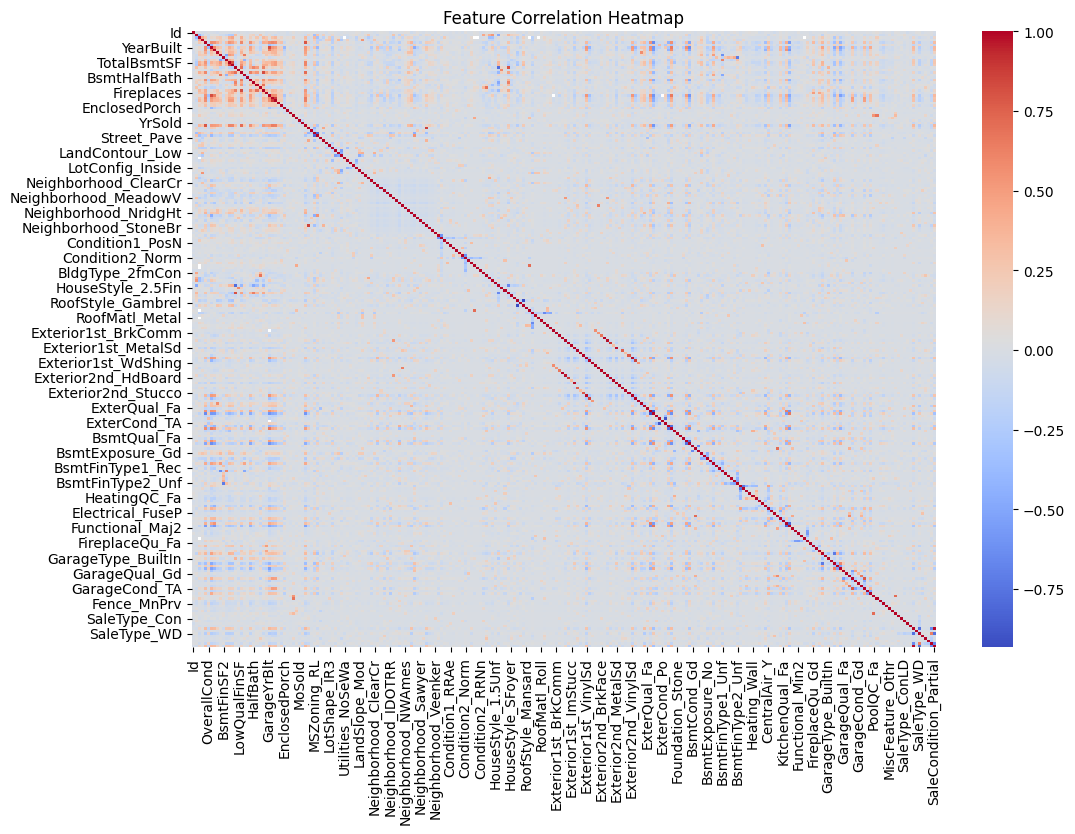

In [8]:
plt.figure(figsize=(12,8))
sns.heatmap(df_encoded.corr(), cmap="coolwarm")
plt.title("Feature Correlation Heatmap")
plt.show()

### top 10 features correlated with SalePrice

SalePrice           1.000000
OverallQual         0.790982
GrLivArea           0.708624
GarageCars          0.640409
GarageArea          0.623431
TotalBsmtSF         0.613581
1stFlrSF            0.605852
FullBath            0.560664
TotRmsAbvGrd        0.533723
YearBuilt           0.522897
YearRemodAdd        0.507101
Foundation_PConc    0.497734
GarageYrBlt         0.486362
MasVnrArea          0.477493
Fireplaces          0.466929
Name: SalePrice, dtype: float64


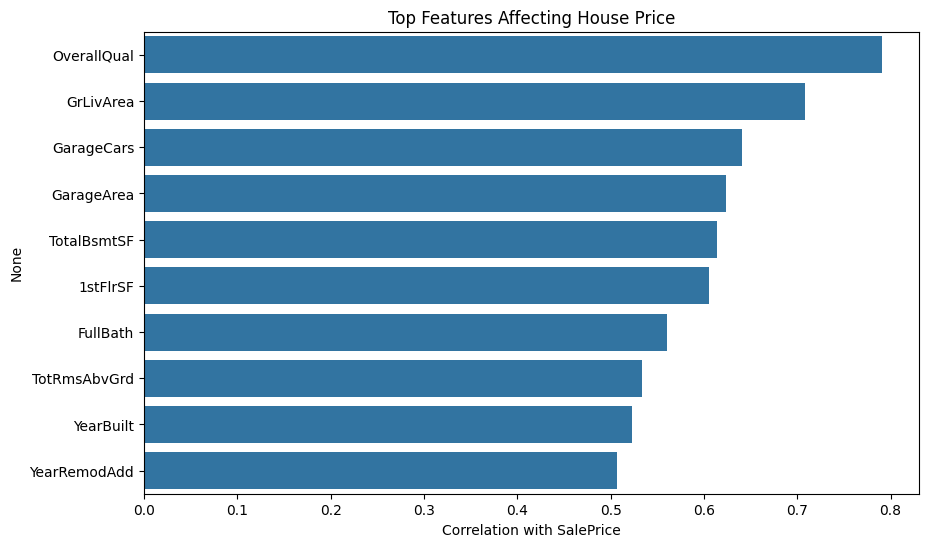

In [9]:

# Correlation with target variable
corr = df_encoded.corr()["SalePrice"].sort_values(ascending=False)

# Print top correlations
print(corr.head(15))
# Select top 10 features correlated with SalePrice
top_features = corr.index[1:11]

plt.figure(figsize=(10,6))
sns.barplot(x=corr[top_features], y=top_features)
plt.title("Top Features Affecting House Price")
plt.xlabel("Correlation with SalePrice")
plt.show()

### Living Area vs Sale Price

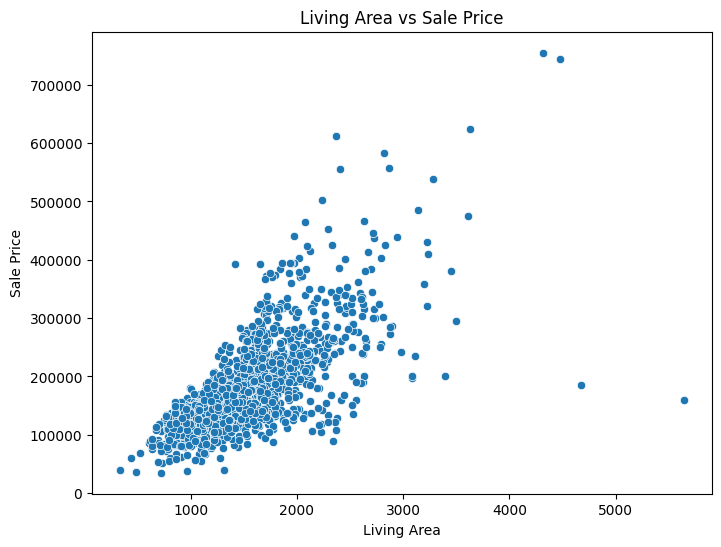

In [10]:
plt.figure(figsize=(8,6))
sns.scatterplot(x=df['GrLivArea'], y=df['SalePrice'])
plt.title("Living Area vs Sale Price")
plt.xlabel("Living Area")
plt.ylabel("Sale Price")
plt.show()

### Box Plot

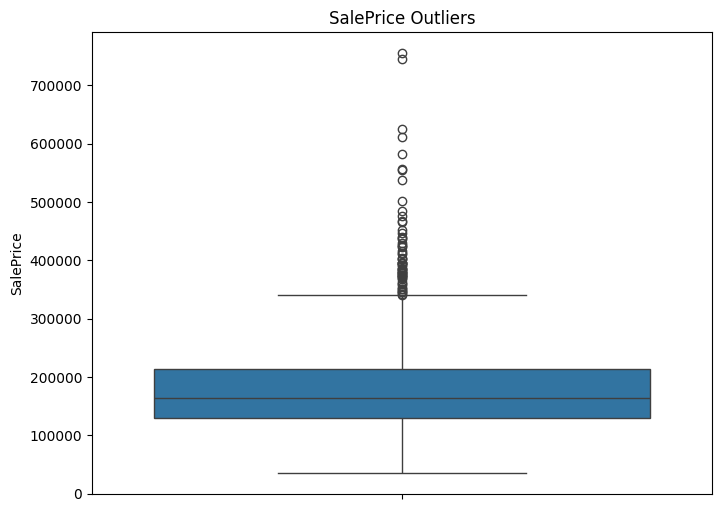

In [11]:
plt.figure(figsize=(8,6))
sns.boxplot(y=df['SalePrice'])
plt.title("SalePrice Outliers")
plt.show()

In [26]:
# Check missing values
print(df_encoded.isnull().sum())

# Fill missing values with median
df_encoded = df_encoded.fillna(df_encoded.median())

# Confirm no missing values remain
print(df_encoded.isnull().sum().sum())

Id                       0
MSSubClass               0
LotFrontage              0
LotArea                  0
OverallQual              0
                        ..
SaleCondition_AdjLand    0
SaleCondition_Alloca     0
SaleCondition_Family     0
SaleCondition_Normal     0
SaleCondition_Partial    0
Length: 246, dtype: int64
0


### Remove outliers

In [13]:
# Remove extreme outliers
df_encoded = df_encoded[df_encoded["GrLivArea"] < 4000]

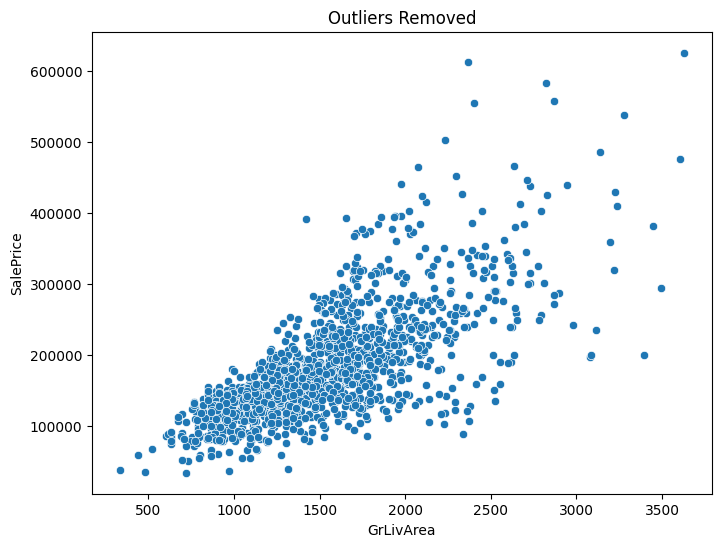

In [14]:
plt.figure(figsize=(8,6))
sns.scatterplot(x=df_encoded["GrLivArea"], y=df_encoded["SalePrice"])
plt.title("Outliers Removed")
plt.show()

### Removing Outliers from SalesPrice

In [15]:
# Calculate Q1 and Q3
Q1 = df_encoded['SalePrice'].quantile(0.25)
Q3 = df_encoded['SalePrice'].quantile(0.75)

# Calculate IQR
IQR = Q3 - Q1

# Define lower and upper limits
lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR

# Remove outliers
df_encoded = df_encoded[(df_encoded['SalePrice'] >= lower_bound) &
                        (df_encoded['SalePrice'] <= upper_bound)]

print("Dataset shape after removing outliers:", df_encoded.shape)

Dataset shape after removing outliers: (1397, 246)


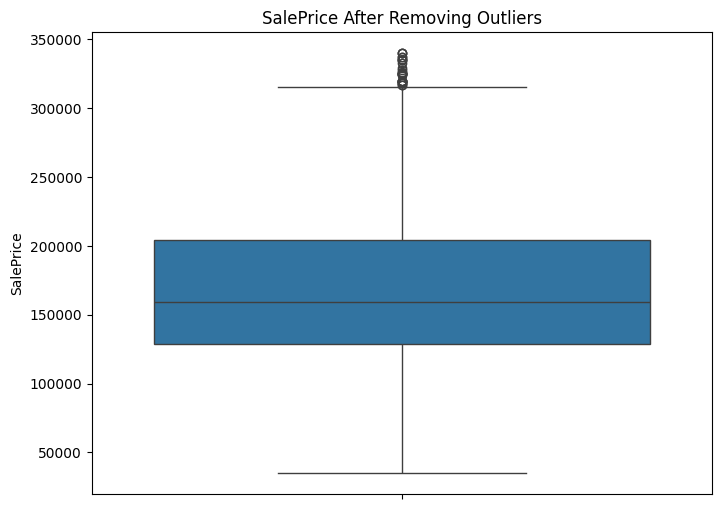

In [16]:
plt.figure(figsize=(8,6))
sns.boxplot(y=df_encoded['SalePrice'])
plt.title("SalePrice After Removing Outliers")
plt.show()

### GrLivArea Outlier

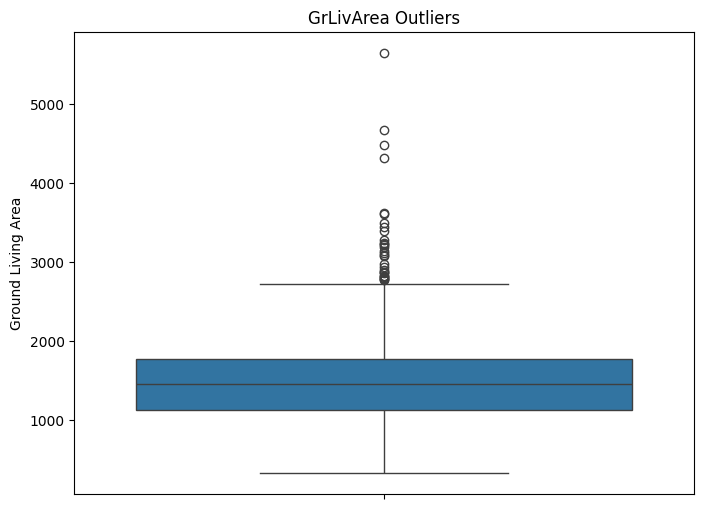

In [17]:
plt.figure(figsize=(8,6))
sns.boxplot(y=df['GrLivArea'])
plt.title("GrLivArea Outliers")
plt.ylabel("Ground Living Area")
plt.show()

### Removing Outliers

In [18]:
Q1 = df_encoded['GrLivArea'].quantile(0.25)
Q3 = df_encoded['GrLivArea'].quantile(0.75)

IQR = Q3 - Q1

lower = Q1 - 1.5 * IQR
upper = Q3 + 1.5 * IQR

df_encoded = df_encoded[(df_encoded['GrLivArea'] >= lower) &
                        (df_encoded['GrLivArea'] <= upper)]

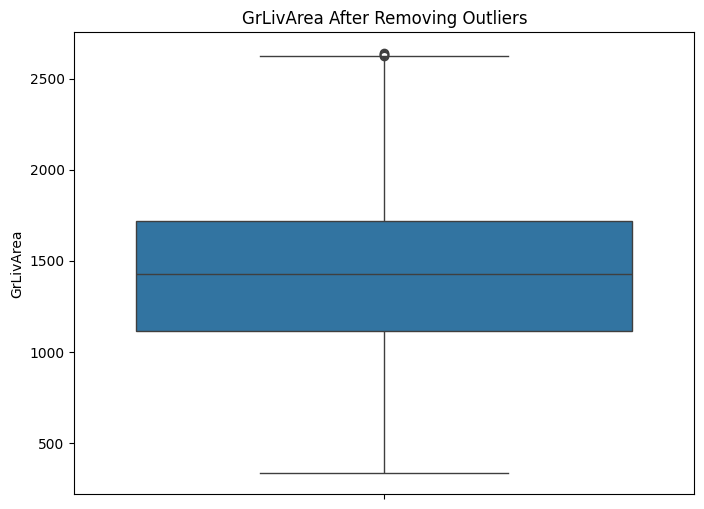

In [19]:
plt.figure(figsize=(8,6))
sns.boxplot(y=df_encoded['GrLivArea'])
plt.title("GrLivArea After Removing Outliers")
plt.show()

###  Separate features and target

In [20]:
X = df_encoded.drop("SalePrice", axis=1)
y = df_encoded["SalePrice"]

# Train-test split
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

# Feature scaling
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

### Training Model

In [21]:
lr = LinearRegression()
lr.fit(X_train, y_train)

y_pred_lr = lr.predict(X_test)

### GradientBoostingRegressor

In [22]:
from sklearn.ensemble import GradientBoostingRegressor

gb = GradientBoostingRegressor(random_state=42)
gb.fit(X_train, y_train)

y_pred_gb = gb.predict(X_test)

### Model Evaluation

In [23]:
from sklearn.metrics import mean_absolute_error, mean_squared_error
import numpy as np

# Linear Regression
mae_lr = mean_absolute_error(y_test, y_pred_lr)
rmse_lr = np.sqrt(mean_squared_error(y_test, y_pred_lr))

print("Linear Regression MAE:", mae_lr)
print("Linear Regression RMSE:", rmse_lr)

# Gradient Boosting
mae_gb = mean_absolute_error(y_test, y_pred_gb)
rmse_gb = np.sqrt(mean_squared_error(y_test, y_pred_gb))

print("Gradient Boosting MAE:", mae_gb)
print("Gradient Boosting RMSE:", rmse_gb)

Linear Regression MAE: 14398.683812643945
Linear Regression RMSE: 19761.258924688158
Gradient Boosting MAE: 13069.008276916444
Gradient Boosting RMSE: 18903.15718580222


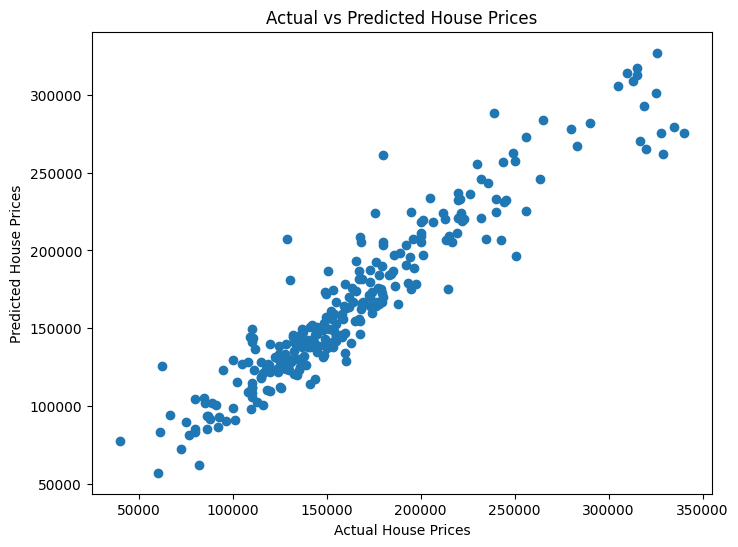

In [24]:


plt.figure(figsize=(8,6))
plt.scatter(y_test, y_pred_gb)
plt.xlabel("Actual House Prices")
plt.ylabel("Predicted House Prices")
plt.title("Actual vs Predicted House Prices")
plt.show()

### Feature Impotance


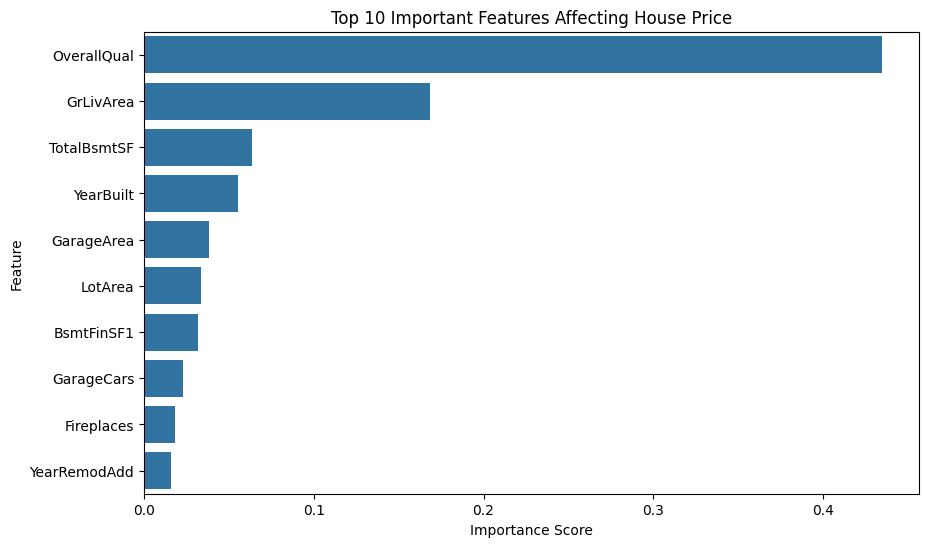

In [25]:
# Get feature importance from the trained Gradient Boosting model
importance = gb.feature_importances_

# Convert to dataframe
feature_importance = pd.DataFrame({
    'Feature': X.columns,
    'Importance': importance
})

# Sort features
feature_importance = feature_importance.sort_values(by='Importance', ascending=False)

# Select top 10 important features
top_features = feature_importance.head(10)

# Plot
plt.figure(figsize=(10,6))
sns.barplot(x='Importance', y='Feature', data=top_features)

plt.title("Top 10 Important Features Affecting House Price")
plt.xlabel("Importance Score")
plt.ylabel("Feature")
plt.show()